# Task 3 (KAN-6): Exploratory Data Analysis and Visualization

**Goal:** explore the cleaned market × crop × week panel: price trends and seasonality by crop and mandi; price against rainfall, temperature and arrivals (including lagged effects); and volatility by crop and mandi.

**Inputs**
- `data/cleaned_mandi_crop_week_panel.csv`: weekly price and arrivals panel (Task 2 output, CEDA / Agmarknet)
- `data/weather_weekly_by_mandi.csv`: weekly rainfall, temperature and humidity per mandi (Open-Meteo, collected by `scripts/collect_weather_openmeteo.py`)

**Outputs**
- 8 charts in `reports/figures/task3/`, each with a one-line takeaway
- `data/panel_with_weather.csv`: price panel joined to weather, used by Task 4

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = ROOT / "data"
FIG = ROOT / "reports" / "figures" / "task3"
FIG.mkdir(parents=True, exist_ok=True)

# Validated categorical palette (fixed order) + neutral inks
CROP_COLORS = {"Tomato": "#2a78d6", "Onion": "#eb6834", "Potato": "#1baf7a"}
CROPS = list(CROP_COLORS)
INK, INK2, MUTED, SURFACE = "#0b0b0b", "#52514e", "#898781", "#fcfcfb"
SEQ = LinearSegmentedColormap.from_list("seq_blue", ["#cde2fb", "#6da7ec", "#2a78d6", "#184f95", "#0d366b"])
DIV = LinearSegmentedColormap.from_list("div_blue_red", ["#184f95", "#6da7ec", "#f0efec", "#ec8a89", "#b52e2e"])

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": MUTED, "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2,
    "text.color": INK, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e6e5e1", "grid.linewidth": 0.8, "axes.axisbelow": True,
    "lines.linewidth": 2, "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
})

def save(fig, name):
    fig.savefig(FIG / f"{name}.png")
    plt.show()

## 1. Load and join the price panel with weather

In [2]:
KEYS = ["state", "district", "market_name", "week_start_date"]
panel = pd.read_csv(DATA / "cleaned_mandi_crop_week_panel.csv", parse_dates=["week_start_date"])
weather = pd.read_csv(DATA / "weather_weekly_by_mandi.csv", parse_dates=["week_start_date"])

df = panel.merge(weather, on=KEYS, how="left", validate="many_to_one")
print("panel:", panel.shape, "| weather:", weather.shape, "| joined:", df.shape)
print("rows without weather:", df["weekly_rainfall_mm"].isna().sum())
print("weeks:", df.week_start_date.min().date(), "to", df.week_start_date.max().date(),
      "|", df.week_start_date.nunique(), "weeks |", df.market_name.nunique(), "mandis |",
      df.state.nunique(), "states")
print(df["trading_days_active"].value_counts().rename("rows by trading days"))

panel: (11130, 11) | weather: (3710, 12) | joined: (11130, 19)
rows without weather: 0
weeks: 2025-09-29 to 2026-09-28 | 53 weeks | 70 mandis | 14 states
trading_days_active
6    10920
2      210
Name: rows by trading days, dtype: int64


The last week (starting 2026-09-28) has only 2 trading days, and its weather covers 5 days, so its weekly arrivals and rainfall totals are not comparable with full weeks. It is **excluded from the EDA** but kept in the saved joined file with a `is_partial_week` flag.

In [3]:
df["is_partial_week"] = df["trading_days_active"] < 6
df = df.sort_values(["crop", "market_name", "week_start_date"]).reset_index(drop=True)
df.to_csv(DATA / "panel_with_weather.csv", index=False)

eda = df[~df["is_partial_week"]].copy()
g = eda.groupby(["crop", "market_name"], observed=True)
eda["pct_change"] = g["weekly_modal_price"].pct_change() * 100
eda["next_pct_change"] = g["pct_change"].shift(-1)
eda["price_index"] = eda["weekly_modal_price"] / g["weekly_modal_price"].transform("mean") * 100

# Calendar quarter is assigned by the Thursday of each Monday-start week (ISO convention)
thursday = eda["week_start_date"] + pd.Timedelta(days=3)
eda["quarter"] = thursday.dt.to_period("Q")
eda["week_of_quarter"] = eda.groupby(["crop", "market_name", "quarter"], observed=True).cumcount() + 1
print("EDA rows:", len(eda))
eda.groupby("crop")["weekly_modal_price"].describe().round(0)

EDA rows: 10920


,count,mean,std,min,25%,50%,75%,max
crop,,,,,,,,
Onion,3640.0,1995.0,143.0,1518.0,1891.0,1994.0,2092.0,2503.0
Potato,3640.0,1553.0,119.0,1189.0,1468.0,1549.0,1633.0,1906.0
Tomato,3640.0,2377.0,160.0,1859.0,2265.0,2372.0,2488.0,2878.0


## 2. Price trends and seasonality
### Chart 1: National average weekly modal price by crop

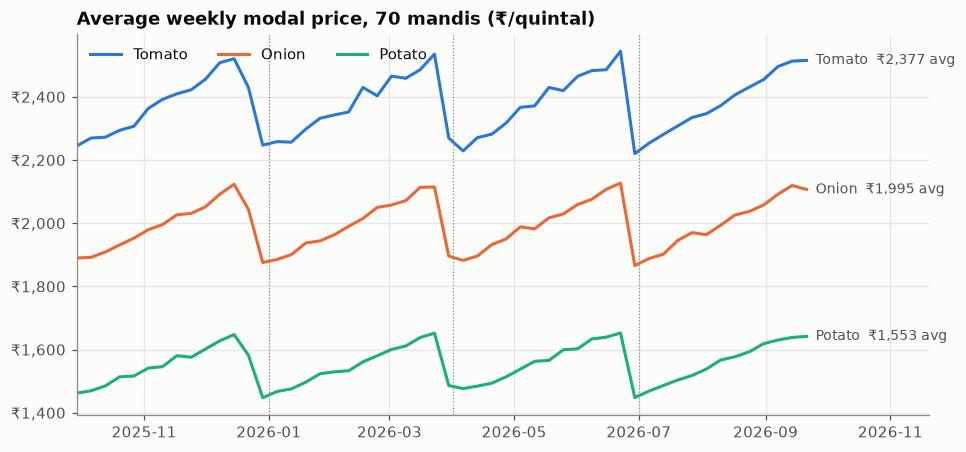

crop
Onion     1995.0
Potato    1553.0
Tomato    2377.0
dtype: float64


In [4]:
nat = eda.groupby(["week_start_date", "crop"])["weekly_modal_price"].mean().unstack()

fig, ax = plt.subplots(figsize=(10, 4.5))
for crop in CROPS:
    ax.plot(nat.index, nat[crop], color=CROP_COLORS[crop], label=crop)
    ax.annotate(f"{crop}  ₹{nat[crop].mean():,.0f} avg", (nat.index[-1], nat[crop].iloc[-1]),
                xytext=(6, 0), textcoords="offset points", va="center", color=INK2, fontsize=9)
for q in pd.date_range("2026-01-01", nat.index.max(), freq="QS"):
    ax.axvline(q, color=MUTED, lw=0.8, ls=":")
ax.set_title("Average weekly modal price, 70 mandis (₹/quintal)")
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("₹{x:,.0f}"))
ax.legend(loc="upper left", frameon=False, ncol=3)
ax.set_xlim(nat.index.min(), nat.index.max() + pd.Timedelta(days=60))
save(fig, "chart1_national_price_trend")

print((nat.mean()).round(0))

**Takeaway:** tomato is the dearest crop (about ₹2,370/q), then onion (about ₹1,990/q) and potato (about ₹1,550/q). All three move together in a repeating sawtooth that resets at each calendar quarter (dotted lines), with no clear trend over the year.

### Chart 2: Seasonality by week of quarter

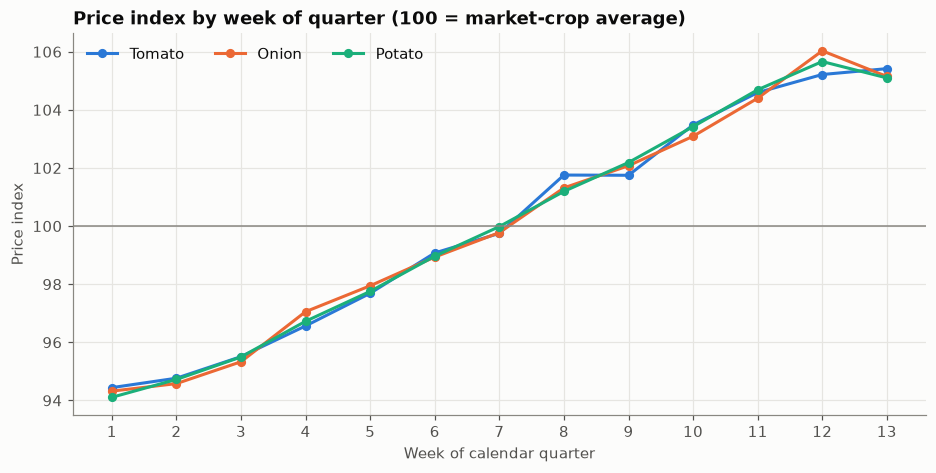

Mean % change in week 1 of a quarter:
 crop
Onion    -10.1
Potato   -10.1
Tomato   -10.1
Name: pct_change, dtype: float64
Mean % change in weeks 2-14:
 crop
Onion     1.07
Potato    1.07
Tomato    1.09
Name: pct_change, dtype: float64


In [5]:
woq = eda.groupby(["crop", "week_of_quarter"])["price_index"].agg(["mean", "std"]).reset_index()

fig, ax = plt.subplots(figsize=(10, 4.5))
for crop in CROPS:
    s = woq[woq.crop == crop]
    ax.plot(s.week_of_quarter, s["mean"], marker="o", ms=5, color=CROP_COLORS[crop], label=crop)
ax.axhline(100, color=MUTED, lw=1)
ax.set_title("Price index by week of quarter (100 = market-crop average)")
ax.set_xlabel("Week of calendar quarter")
ax.set_ylabel("Price index")
ax.set_xticks(range(1, 14))
ax.legend(frameon=False, ncol=3, loc="upper left")
save(fig, "chart2_week_of_quarter_seasonality")

w1 = eda[eda.week_of_quarter == 1]
first_week_drop = w1.groupby("crop")["pct_change"].mean().round(1)
other_weeks = eda[eda.week_of_quarter > 1].groupby("crop")["pct_change"].mean().round(2)
print("Mean % change in week 1 of a quarter:\n", first_week_drop)
print("Mean % change in weeks 2-14:\n", other_weeks)

**Takeaway:** the strongest pattern in the data is a **quarterly cycle**. Prices sit about 6% below average in week 1 of each quarter (index ≈ 94), climb about 1% a week to a peak about 5% above average in weeks 12-13 (index ≈ 105), then drop about 10% when the next quarter starts. The best buying window is early in the quarter.

### Chart 3: Price index by state and week (are mandis in sync?)

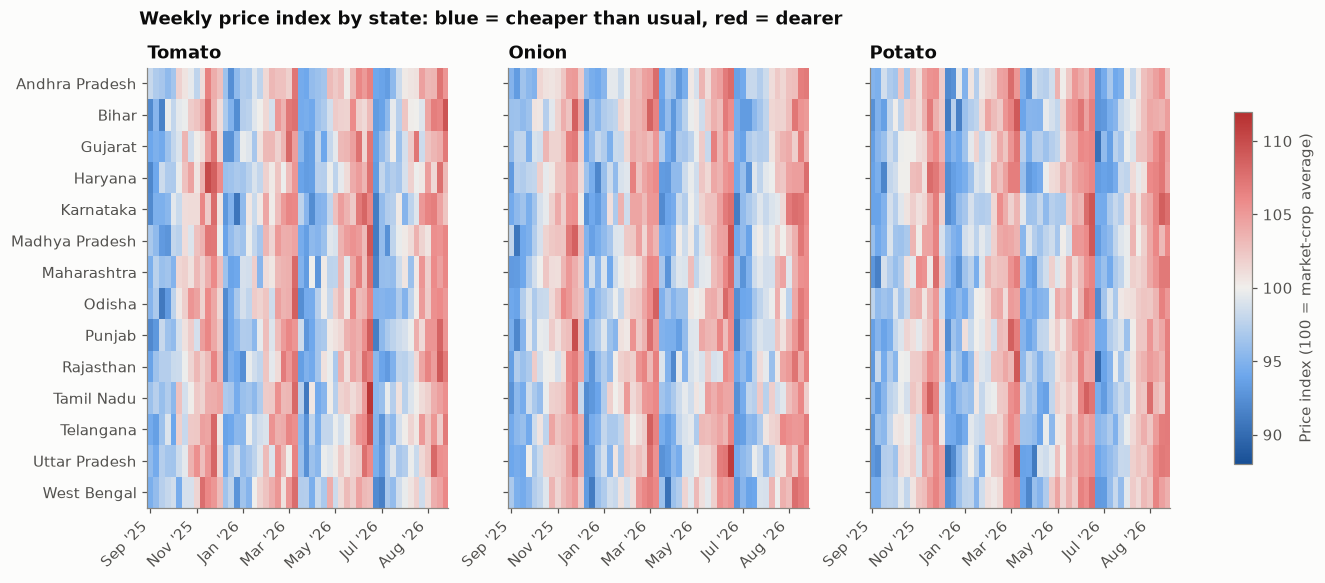

Tomato: mean cross-mandi correlation = 0.48, share of variance from national weekly mean = 35%
Onion: mean cross-mandi correlation = 0.50, share of variance from national weekly mean = 31%
Potato: mean cross-mandi correlation = 0.54, share of variance from national weekly mean = 28%


In [6]:
st = eda.groupby(["crop", "state", "week_start_date"])["price_index"].mean().reset_index()
fig, axes = plt.subplots(1, 3, figsize=(15, 5.2), sharey=True)
for ax, crop in zip(axes, CROPS):
    m = st[st.crop == crop].pivot(index="state", columns="week_start_date", values="price_index")
    im = ax.imshow(m.values, aspect="auto", cmap=DIV, vmin=88, vmax=112)
    ax.set_title(crop)
    ax.set_yticks(range(len(m.index)), m.index)
    ticks = range(0, m.shape[1], 8)
    ax.set_xticks(list(ticks), [m.columns[i].strftime("%b '%y") for i in ticks], rotation=45, ha="right")
    ax.grid(False)
fig.colorbar(im, ax=axes, shrink=0.8, label="Price index (100 = market-crop average)")
fig.suptitle("Weekly price index by state: blue = cheaper than usual, red = dearer", x=0.12, ha="left",
             fontweight="bold")
save(fig, "chart3_state_week_price_heatmap")

# How much of price variation is the shared national cycle?
for crop in CROPS:
    piv = eda[eda.crop == crop].pivot(index="week_start_date", columns="market_name", values="weekly_modal_price")
    c = piv.corr().values
    share = piv.mean(axis=1).var() / piv.stack().var()
    print(f"{crop}: mean cross-mandi correlation = {c[np.triu_indices_from(c, 1)].mean():.2f}, "
          f"share of variance from national weekly mean = {share:.0%}")

**Takeaway:** the cycle is **synchronised across all 14 states**: the same vertical bands appear in every row. Mandis are moderately correlated with each other (r ≈ 0.48), and the shared national weekly level explains about a third of the price variance. The rest is mandi-level noise around that cycle.

## 3. Price against arrivals, rainfall and temperature
### Chart 4: Price vs arrivals (within each mandi)

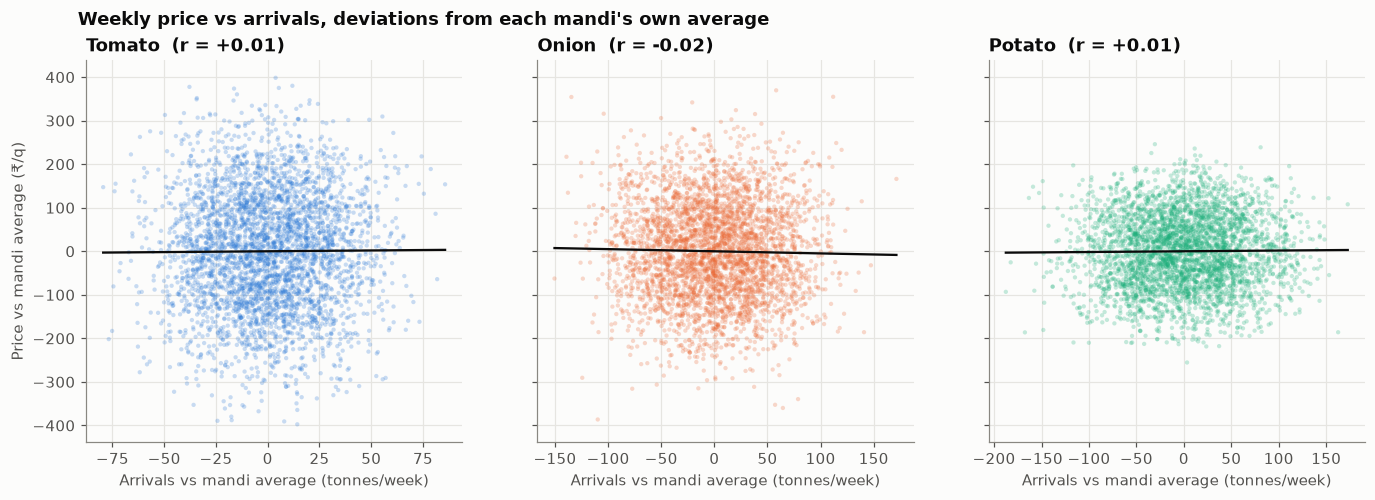

In [7]:
# Remove each market-crop's own average so we compare weeks within the same mandi
for col in ["weekly_modal_price", "weekly_total_arrivals"]:
    eda[col + "_dev"] = eda[col] - eda.groupby(["crop", "market_name"])[col].transform("mean")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for ax, crop in zip(axes, CROPS):
    s = eda[eda.crop == crop]
    ax.scatter(s.weekly_total_arrivals_dev, s.weekly_modal_price_dev, s=8, alpha=0.25,
               color=CROP_COLORS[crop], edgecolors="none")
    b = np.polyfit(s.weekly_total_arrivals_dev, s.weekly_modal_price_dev, 1)
    xs = np.linspace(s.weekly_total_arrivals_dev.min(), s.weekly_total_arrivals_dev.max(), 50)
    ax.plot(xs, np.polyval(b, xs), color=INK, lw=1.5)
    r = s[["weekly_total_arrivals_dev", "weekly_modal_price_dev"]].corr().iloc[0, 1]
    ax.set_title(f"{crop}  (r = {r:+.2f})")
    ax.set_xlabel("Arrivals vs mandi average (tonnes/week)")
axes[0].set_ylabel("Price vs mandi average (₹/q)")
fig.suptitle("Weekly price vs arrivals, deviations from each mandi's own average", x=0.12, ha="left",
             fontweight="bold")
save(fig, "chart4_price_vs_arrivals")

**Takeaway:** within a mandi, weeks with heavier arrivals do **not** show lower prices (r is about 0 for all three crops). The textbook supply effect is not visible in this panel, so arrivals on their own are unlikely to be a strong predictor.

### Chart 5: Next-week price change by rainfall and heat

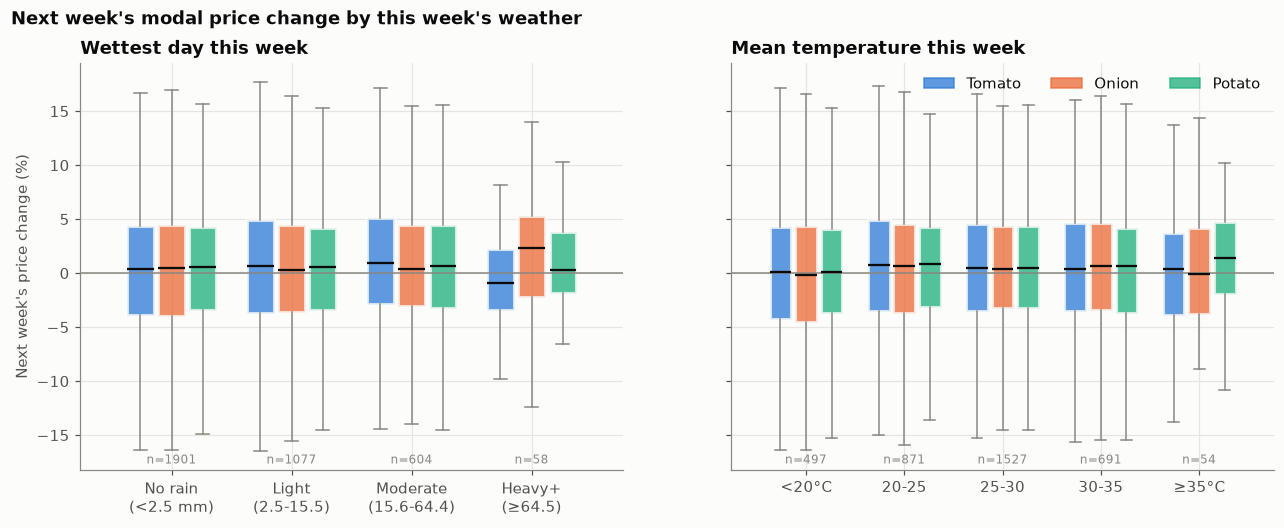

crop                   Onion  Potato  Tomato
rain_cat                                    
No rain\n(<2.5 mm)      0.48    0.54    0.35
Light\n(2.5-15.5)       0.26    0.59    0.68
Moderate\n(15.6-64.4)   0.39    0.66    0.90
Heavy+\n(≥64.5)         2.33    0.25   -0.94
crop      Onion  Potato  Tomato
temp_cat                       
<20°C     -0.20    0.09    0.13
20-25      0.65    0.81    0.76
25-30      0.40    0.50    0.45
30-35      0.63    0.66    0.42
≥35°C     -0.10    1.40    0.35


In [8]:
# IMD daily rainfall categories applied to the wettest day of the week
rain_bins = [-0.1, 2.4, 15.5, 64.4, np.inf]
rain_lbl = ["No rain\n(<2.5 mm)", "Light\n(2.5-15.5)", "Moderate\n(15.6-64.4)", "Heavy+\n(≥64.5)"]
eda["rain_cat"] = pd.cut(eda["max_daily_rainfall_mm"], rain_bins, labels=rain_lbl)
temp_bins = [-np.inf, 20, 25, 30, 35, np.inf]
temp_lbl = ["<20°C", "20-25", "25-30", "30-35", "≥35°C"]
eda["temp_cat"] = pd.cut(eda["weekly_temp_mean_c"], temp_bins, labels=temp_lbl)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharey=True)
for ax, cat, lbls, title in [(axes[0], "rain_cat", rain_lbl, "Wettest day this week"),
                              (axes[1], "temp_cat", temp_lbl, "Mean temperature this week")]:
    width = 0.26
    for i, crop in enumerate(CROPS):
        s = eda[eda.crop == crop]
        data = [s.loc[s[cat] == l, "next_pct_change"].dropna() for l in lbls]
        pos = np.arange(len(lbls)) + (i - 1) * width
        bp = ax.boxplot(data, positions=pos, widths=width * 0.85, patch_artist=True, showfliers=False,
                        medianprops=dict(color=INK, lw=1.5), whiskerprops=dict(color=MUTED),
                        capprops=dict(color=MUTED))
        for patch in bp["boxes"]:
            patch.set(facecolor=CROP_COLORS[crop], alpha=0.75, edgecolor=SURFACE, lw=2)
    ax.set_xticks(range(len(lbls)), lbls)
    ax.axhline(0, color=MUTED, lw=1)
    ax.set_title(title)
    counts = eda[eda.crop == "Tomato"][cat].value_counts().reindex(lbls)
    for j, n in enumerate(counts):
        ax.annotate(f"n={n}", (j, ax.get_ylim()[0]), xytext=(0, 4), textcoords="offset points",
                    ha="center", fontsize=8, color=MUTED)
axes[0].set_ylabel("Next week's price change (%)")
handles = [plt.Rectangle((0, 0), 1, 1, color=CROP_COLORS[c], alpha=0.75) for c in CROPS]
axes[1].legend(handles, CROPS, frameon=False, ncol=3, loc="upper right")
fig.suptitle("Next week's modal price change by this week's weather", x=0.08, ha="left", fontweight="bold")
save(fig, "chart5_next_week_change_by_weather")

print(eda.groupby(["rain_cat", "crop"], observed=True)["next_pct_change"].median().unstack().round(2))
print(eda.groupby(["temp_cat", "crop"], observed=True)["next_pct_change"].median().unstack().round(2))

**Takeaway:** next week's price change looks much the same whether this week was dry or had heavy rain, cool or hot. The medians stay within about ±1 percentage point of each other. The only exception is the small heavy-rain bucket (58 mandi-weeks per crop), where onion and tomato move in *opposite* directions, which points to noise rather than a weather effect. Single-week weather events do not consistently move mandi prices in this data.

### Chart 6: Lagged effects: correlation of drivers with next week's price change

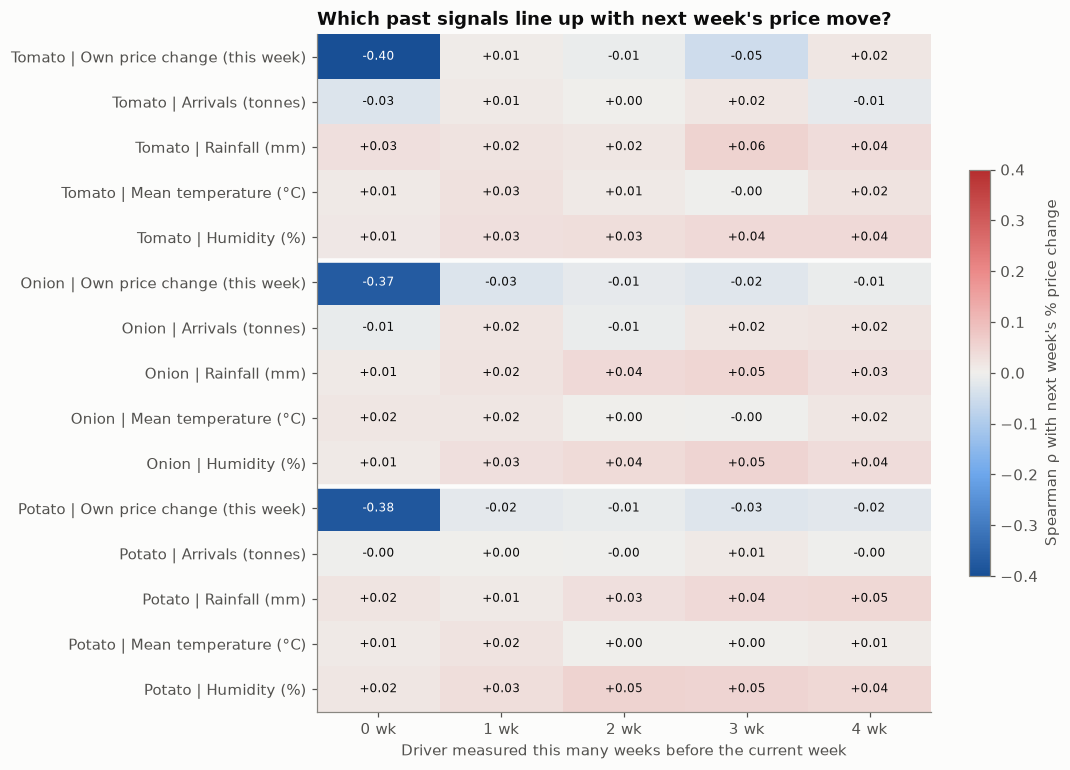

,lag 0,lag 1,lag 2,lag 3,lag 4
Tomato | Own price change (this week),-0.403,0.008,-0.008,-0.051,0.016
Tomato | Arrivals (tonnes),-0.029,0.010,0.001,0.017,-0.013
Tomato | Rainfall (mm),0.030,0.023,0.017,0.056,0.037
Tomato | Mean temperature (°C),0.009,0.025,0.010,-0.003,0.023
Tomato | Humidity (%),0.013,0.029,0.034,0.043,0.043
Onion | Own price change (this week),-0.372,-0.030,-0.014,-0.023,-0.008
Onion | Arrivals (tonnes),-0.011,0.022,-0.009,0.017,0.020
Onion | Rainfall (mm),0.012,0.025,0.042,0.050,0.031
Onion | Mean temperature (°C),0.017,0.018,0.002,-0.001,0.016
Onion | Humidity (%),0.011,0.031,0.040,0.050,0.036


In [9]:
drivers = {
    "Own price change (this week)": "pct_change",
    "Arrivals (tonnes)": "weekly_total_arrivals",
    "Rainfall (mm)": "weekly_rainfall_mm",
    "Mean temperature (°C)": "weekly_temp_mean_c",
    "Humidity (%)": "weekly_humidity_mean_pct",
}
LAGS = range(0, 5)
rows = []
g = eda.groupby(["crop", "market_name"], observed=True)
for crop in CROPS:
    for name, col in drivers.items():
        vals = []
        for lag in LAGS:
            x = g[col].shift(lag)
            mask = (eda.crop == crop)
            vals.append(pd.concat([x[mask], eda.loc[mask, "next_pct_change"]], axis=1)
                        .corr(method="spearman").iloc[0, 1])
        rows.append(pd.Series(vals, index=[f"lag {l}" for l in LAGS], name=f"{crop} | {name}"))
lagcorr = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(lagcorr.values, cmap=DIV, vmin=-0.4, vmax=0.4, aspect="auto")
ax.set_yticks(range(len(lagcorr)), lagcorr.index)
ax.set_xticks(range(len(LAGS)), [f"{l} wk" for l in LAGS])
ax.set_xlabel("Driver measured this many weeks before the current week")
ax.grid(False)
for (i, j), v in np.ndenumerate(lagcorr.values):
    ax.text(j, i, f"{v:+.2f}", ha="center", va="center", fontsize=8,
            color="#ffffff" if abs(v) > 0.25 else INK)
for y in [len(drivers) - 0.5, 2 * len(drivers) - 0.5]:
    ax.axhline(y, color=SURFACE, lw=3)
fig.colorbar(im, ax=ax, shrink=0.6, label="Spearman ρ with next week's % price change")
ax.set_title("Which past signals line up with next week's price move?")
save(fig, "chart6_lagged_correlation_heatmap")
lagcorr.round(3)

**Takeaway:** weather and arrivals at lags of 0-4 weeks have almost **no correlation** (|ρ| ≤ 0.06) with next week's price move. The only strong signal is the price's own recent change (ρ ≈ -0.37 to -0.40 at lag 0, i.e. **mean reversion**: a big rise this week tends to be followed by a fall). Price-history and calendar features should matter more than weather.

## 4. Volatility by crop and mandi
### Chart 7: Weekly price volatility by state and crop

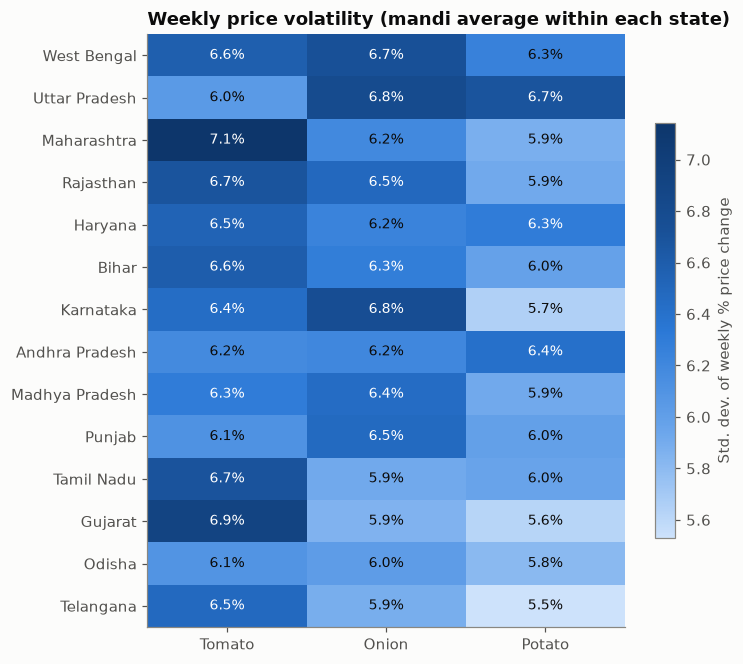

Volatility by crop (std of weekly % change):
crop
Onion     6.29
Potato    5.97
Tomato    6.46
Name: pct_change, dtype: float64

Most volatile mandi-crop pairs:
  crop       state           market_name  vol
Tomato Maharashtra      Pune Apmc Market 7.86
Tomato   Karnataka Davangere Apmc Market 7.72
Tomato   Rajasthan      Kota Apmc Market 7.67
 Onion   Rajasthan     Alwar Apmc Market 7.60
Tomato Maharashtra    Nagpur Apmc Market 7.53

Least volatile mandi-crop pairs:
  crop          state                 market_name  vol
Potato      Rajasthan           Alwar Apmc Market 4.44
 Onion     Tamil Nadu Tiruchirappalli Apmc Market 4.47
 Onion        Gujarat       Ahmedabad Apmc Market 4.75
Potato Madhya Pradesh        Jabalpur Apmc Market 4.84
 Onion         Odisha         Cuttack Apmc Market 4.90


In [10]:
vol_mkt = eda.groupby(["crop", "state", "market_name"])["pct_change"].std().reset_index(name="vol")
vol_state = vol_mkt.groupby(["state", "crop"])["vol"].mean().unstack()[CROPS]
vol_state = vol_state.loc[vol_state.mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(7, 7))
im = ax.imshow(vol_state.values, cmap=SEQ, aspect="auto")
ax.set_xticks(range(3), CROPS)
ax.set_yticks(range(len(vol_state)), vol_state.index)
ax.grid(False)
for (i, j), v in np.ndenumerate(vol_state.values):
    ax.text(j, i, f"{v:.1f}%", ha="center", va="center", fontsize=9,
            color="#ffffff" if v > vol_state.values.mean() else INK)
fig.colorbar(im, ax=ax, shrink=0.7, label="Std. dev. of weekly % price change")
ax.set_title("Weekly price volatility (mandi average within each state)")
save(fig, "chart7_volatility_state_crop")

print("Volatility by crop (std of weekly % change):")
print(eda.groupby("crop")["pct_change"].std().round(2))
print("\nMost volatile mandi-crop pairs:")
print(vol_mkt.nlargest(5, "vol").round(2).to_string(index=False))
print("\nLeast volatile mandi-crop pairs:")
print(vol_mkt.nsmallest(5, "vol").round(2).to_string(index=False))

**Takeaway:** volatility is similar across crops (tomato highest at about 6.5% a week, potato lowest at about 6.0%) and across states (about 5.5-7.1%). Tomato in Maharashtra and Gujarat is the most volatile state-crop combination, and Pune tomato is the most volatile single mandi (7.9%). No single state or crop is a clear outlier, so one model across all mandis is reasonable.

### Chart 8: Distribution of weekly price changes and the rise / flat / fall band

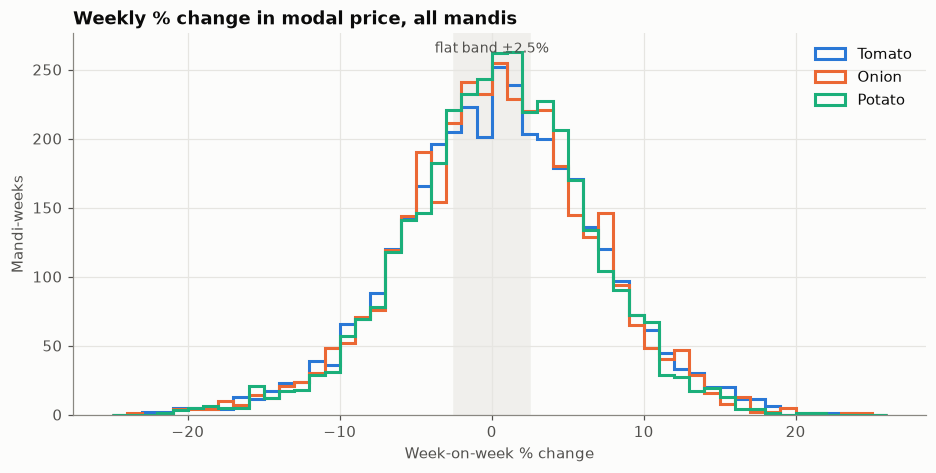

Target class shares with ±2.5% band:
next_pct_change   fall   flat   rise
crop                                
Onion            0.304  0.331  0.365
Potato           0.288  0.350  0.362
Tomato           0.315  0.317  0.368


In [11]:
BAND = 2.5  # ±% band for the 'flat' class
fig, ax = plt.subplots(figsize=(10, 4.5))
bins = np.arange(-25, 27, 1)
for crop in CROPS:
    ax.hist(eda.loc[eda.crop == crop, "pct_change"].dropna(), bins=bins, histtype="step", lw=2,
            color=CROP_COLORS[crop], label=crop)
ax.axvspan(-BAND, BAND, color="#f0efec", zorder=0)
ax.annotate(f"flat band ±{BAND}%", (0, ax.get_ylim()[1] * 0.95), ha="center", color=INK2, fontsize=9)
ax.set_title("Weekly % change in modal price, all mandis")
ax.set_xlabel("Week-on-week % change")
ax.set_ylabel("Mandi-weeks")
ax.legend(frameon=False)
save(fig, "chart8_weekly_change_distribution")

target = pd.cut(eda["next_pct_change"], [-np.inf, -BAND, BAND, np.inf], labels=["fall", "flat", "rise"])
print("Target class shares with ±2.5% band:")
print(pd.crosstab(eda["crop"], target, normalize="index").round(3))

**Takeaway:** weekly changes centre near 0% with a spread of about ±6.5%. A **±2.5% flat band** splits next-week moves into roughly balanced classes (about 29-32% fall, 32-35% flat, 36-37% rise per crop), so it is a sensible, data-justified choice for the README's ±X% target.

## 5. Summary of findings

| # | Chart | One-line takeaway |
|---|---|---|
| 1 | National price trend | Tomato > onion > potato; all three move together in a quarterly sawtooth with no yearly trend. |
| 2 | Week-of-quarter seasonality | Prices climb about 1% a week through a quarter and drop about 10% at each quarter start, so buy early in the quarter. |
| 3 | State × week heatmap | The cycle is synchronised across all 14 states; the national level explains about a third of price variance. |
| 4 | Price vs arrivals | No visible within-mandi supply-price relationship (r ≈ 0). |
| 5 | Next-week change by weather | Rainfall and temperature categories do not consistently shift next week's price change. |
| 6 | Lagged correlations | Weather and arrivals at lags 0-4 have \|ρ\| ≤ 0.06; own-price mean reversion (ρ ≈ -0.38) is the main signal. |
| 7 | Volatility heatmap | Weekly volatility is about 5.5-7% everywhere; tomato in Maharashtra and Gujarat is the most volatile. |
| 8 | Change distribution | A ±2.5% band gives balanced fall/flat/rise classes. |

### Implications for Task 4 (feature engineering)
- Prioritise **price-history features** (lags, recent % change, rolling mean/std, distance from rolling mean) and **calendar features** (week of quarter, quarter, month).
- Keep weather and arrival features, but expect weak signal. Test them with lags and rolling windows rather than single-week values.

### Data observations to raise with the team
- The price series is **unusually regular**: the same quarterly sawtooth appears in all 70 mandis and all three crops, the within-mandi coefficient of variation is only about 5.6%, and prices do not respond to arrivals. Real tomato prices usually swing much more and react to supply shocks. It is worth confirming with the collector that the CEDA/Agmarknet extraction returned genuine per-market history, not a fallback or interpolated series, before drawing business conclusions.
- Only 1 year of history (Sep 2025 to Sep 2026) is available, below the 3-5 years in the README scope, so yearly seasonality cannot be confirmed.